# 13 — Walk-Forward Analysis

## Purpose
Validate that the best strategy from notebook 12 is NOT overfit to the specific data period.

## Why this matters
Standard backtesting selects parameters on the SAME data you test on.
This leads to overfitting: parameters that worked historically may not work live.

**Walk-forward testing** solves this by:
1. Training on in-sample data (e.g. first 70%)
2. Testing on out-of-sample data (last 30%)
3. Repeating with rolling windows
4. The out-of-sample performance = the REAL expected performance

## Methodology
For the OB strategy with fixed parameters (not optimized), walk-forward
tests that the statistical edge is stable across different time periods.

## Interpretation
- IS performance ≈ OOS performance → ROBUST strategy, good to trade live
- IS >> OOS → OVERFIT, parameters need rethinking
- OOS > IS → Lucky in test window, check larger sample

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from strategy.ob_core import add_candle_features
from strategy.ob_signals import list_ob_signals_enhanced, OBSignalConfig, get_passed_signals

plt.style.use('dark_background')
plt.rcParams.update({'figure.figsize': (20, 8)})

SYMBOL    = 'XAUUSDT'
RISK_USDT = 20.0
RR        = 2.0

m5 = pd.read_csv(f'../notebooks/data/{SYMBOL}/M5/ohlcv.csv', index_col=0, parse_dates=True)
if m5.index.tzinfo is None:
    m5.index = m5.index.tz_localize('UTC')
m5 = add_candle_features(m5.sort_index())

print(f'Dataset: {len(m5):,} M5 bars')
print(f'Period : {m5.index[0].date()} to {m5.index[-1].date()}')

Dataset: 19,798 M5 bars
Period : 2026-03-09 to 2026-05-17


In [ ]:
# ── Walk-forward setup ─────────────────────────────────────────────────────
# Use the best config from notebook 12
# Adjust based on your findings there
BEST_CONFIG = OBSignalConfig(
    rr=RR,
    session_filter_enabled=True,
    allow_london=True,
    allow_new_york=True,
    allow_overlap=True,
    require_bos=True,
    require_fvg=True,
    regime_filter_enabled=True,
    skip_ranging=True,
)

FEE_RATE = 0.00055  # 0.055% per side (entry + exit)

def backtest_window(m5_window, config, risk=20.0, start_balance=10000.0):
    sigs  = list_ob_signals_enhanced(m5_window, risk_cash=risk, config=config)
    sigs  = get_passed_signals(sigs)
    trades = []
    balance = start_balance

    for _, sig in sigs.iterrows():
        bar   = int(sig['signal_bar_index'])
        side  = sig['side']
        entry = float(sig['entry'])
        sl    = float(sig['sl'])
        tp    = float(sig['tp'])
        qty   = risk / max(abs(entry - sl), 1e-9)

        result = exit_p = exit_t = None
        for j in range(bar + 1, min(bar + 300, len(m5_window))):
            b = m5_window.iloc[j]
            hit_sl = b['low'] <= sl if side == 'buy' else b['high'] >= sl
            hit_tp = b['high'] >= tp if side == 'buy' else b['low'] <= tp
            if hit_sl and hit_tp:
                exit_p, result = sl, 'loss'
            elif hit_sl:
                exit_p, result = sl, 'loss'
            elif hit_tp:
                exit_p, result = tp, 'win'
            if result:
                exit_t = m5_window.index[j]
                break

        if result is None:
            continue

        fee = (entry + exit_p) * qty * FEE_RATE
        pnl = ((exit_p - entry) * qty if side == 'buy' else (entry - exit_p) * qty) - fee
        balance += pnl
        trades.append({'result': result, 'pnl': pnl})

    if not trades:
        return {'trades': 0, 'win_rate': None, 'expectancy': None, 'total_pnl': 0}

    df = pd.DataFrame(trades)
    wr = (df['result'] == 'win').mean()
    aw = df[df['result']=='win']['pnl'].mean() if len(df[df['result']=='win'])>0 else 0
    al = df[df['result']=='loss']['pnl'].mean() if len(df[df['result']=='loss'])>0 else 0
    return {
        'trades'    : len(df),
        'win_rate'  : round(wr * 100, 1),
        'expectancy': round(wr * aw + (1-wr) * al, 2),
        'total_pnl' : round(df['pnl'].sum(), 2),
    }

print('Walk-forward engine ready.')

In [3]:
# ── Walk-forward windows ────────────────────────────────────────────────────
n_bars     = len(m5)
window_size = n_bars // 4   # each fold = 25% of data
step_size   = window_size   # no overlap (anchored WF)

wf_results = []
print(f'Walk-forward with window={window_size} bars each')
print(f'Total folds: {n_bars // step_size}')
print()

for fold in range(n_bars // step_size):
    fold_start = fold * step_size
    fold_end   = fold_start + window_size

    if fold_end > n_bars:
        break

    window = m5.iloc[fold_start:fold_end]
    metrics = backtest_window(window, BEST_CONFIG)

    period_label = f"{window.index[0].date()} – {window.index[-1].date()}"
    wf_results.append({
        'fold'        : fold + 1,
        'period'      : period_label,
        'start'       : window.index[0],
        'end'         : window.index[-1],
        **metrics,
    })

    print(f'Fold {fold+1}: {period_label} | '
          f'trades={metrics["trades"]} '
          f'WR={metrics["win_rate"]}% '
          f'exp={metrics["expectancy"]} '
          f'PnL={metrics["total_pnl"]}')

wf_df = pd.DataFrame(wf_results)

Walk-forward with window=4949 bars each
Total folds: 4

Fold 1: 2026-03-09 – 2026-03-26 | trades=22 WR=54.5% exp=12.73 PnL=280.0
Fold 2: 2026-03-26 – 2026-04-12 | trades=16 WR=68.8% exp=21.25 PnL=340.0
Fold 3: 2026-04-12 – 2026-04-29 | trades=0 WR=None% exp=None PnL=0
Fold 4: 2026-04-29 – 2026-05-17 | trades=18 WR=61.1% exp=16.67 PnL=300.0


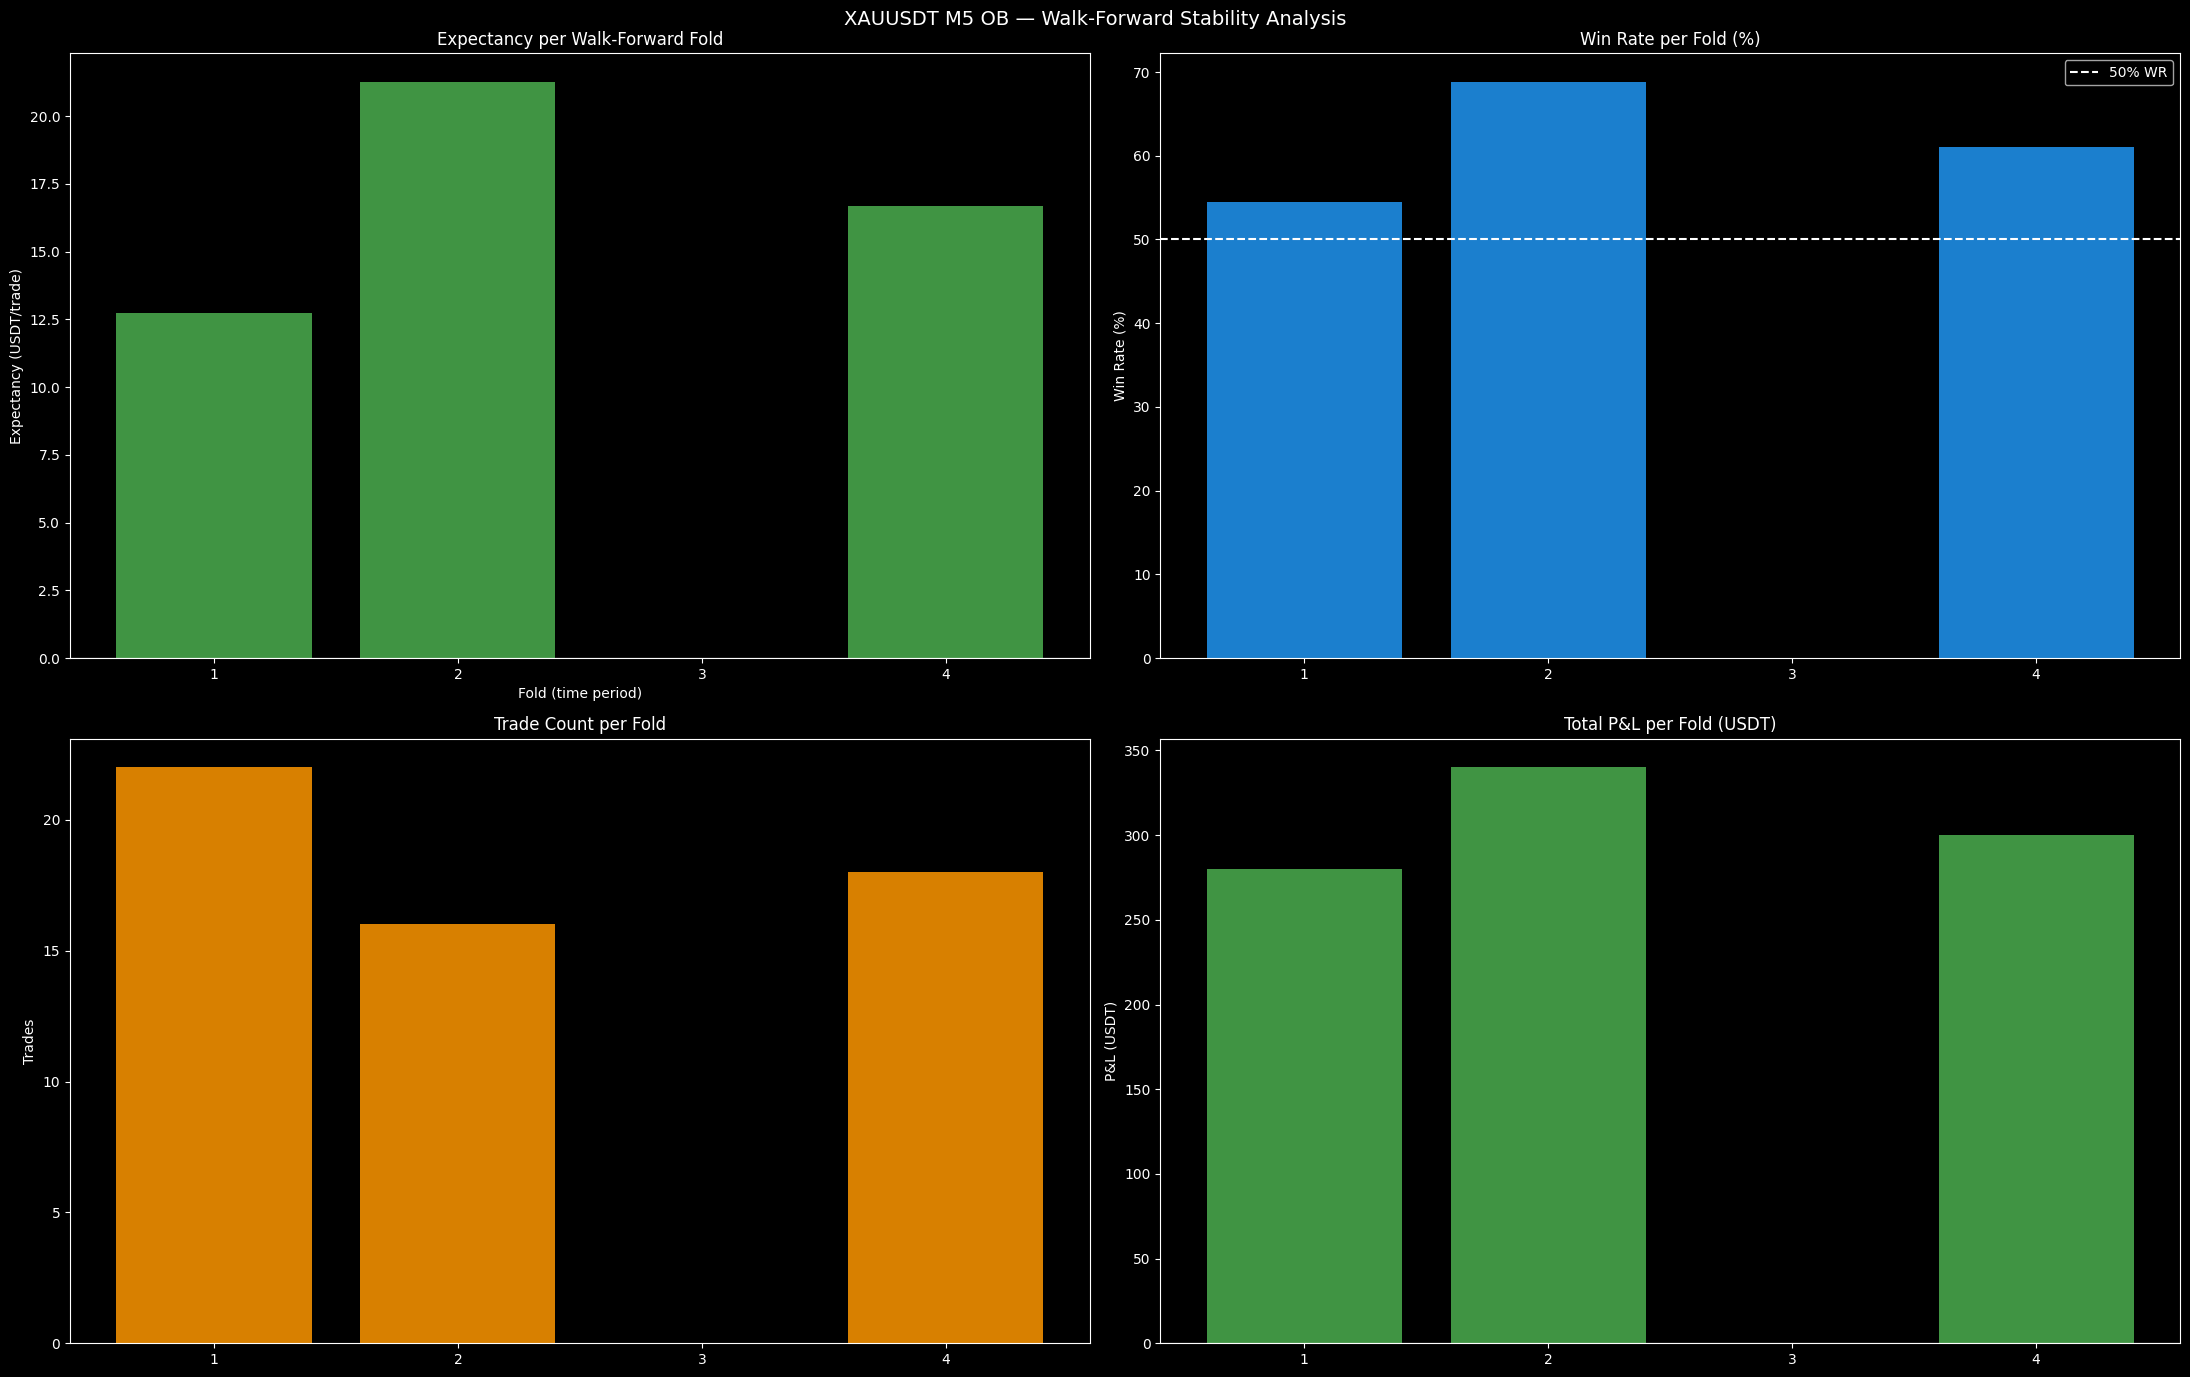


=== WALK-FORWARD SUMMARY ===
Positive folds: 3/4 (75%)
Mean expectancy: 12.66 USDT/trade
Std expectancy : 9.13 USDT/trade
Mean win rate  : 46.1%

✅ Strategy is ROBUST — positive in ≥70% of time periods.
   Safe to deploy with the configured filters.


In [4]:
# ── Walk-forward visualization ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(22, 14))

# Expectancy per fold
folds = wf_df['fold'].astype(str)
exps  = wf_df['expectancy'].fillna(0)
colors = ['#4CAF50' if e > 0 else '#F44336' for e in exps]
axes[0,0].bar(folds, exps, color=colors, alpha=0.85)
axes[0,0].axhline(0, color='white', linewidth=0.8)
axes[0,0].set_title('Expectancy per Walk-Forward Fold')
axes[0,0].set_xlabel('Fold (time period)')
axes[0,0].set_ylabel('Expectancy (USDT/trade)')

# Win rate per fold
wrs = wf_df['win_rate'].fillna(0)
axes[0,1].bar(folds, wrs, color='#2196F3', alpha=0.85)
axes[0,1].axhline(50, color='white', linestyle='--', label='50% WR')
axes[0,1].set_title('Win Rate per Fold (%)')
axes[0,1].set_ylabel('Win Rate (%)')
axes[0,1].legend()

# Trade count per fold
axes[1,0].bar(folds, wf_df['trades'].fillna(0), color='#FF9800', alpha=0.85)
axes[1,0].set_title('Trade Count per Fold')
axes[1,0].set_ylabel('Trades')

# Total P&L per fold
pnls  = wf_df['total_pnl'].fillna(0)
pcolors = ['#4CAF50' if p > 0 else '#F44336' for p in pnls]
axes[1,1].bar(folds, pnls, color=pcolors, alpha=0.85)
axes[1,1].axhline(0, color='white', linewidth=0.8)
axes[1,1].set_title('Total P&L per Fold (USDT)')
axes[1,1].set_ylabel('P&L (USDT)')

plt.suptitle(f'{SYMBOL} M5 OB — Walk-Forward Stability Analysis', fontsize=14)
plt.tight_layout()
plt.savefig('../notebooks_ob/results/13_walk_forward.png', dpi=100, bbox_inches='tight')
plt.show()

# Summary
positive_folds = (wf_df['expectancy'].fillna(0) > 0).sum()
total_folds = len(wf_df)
print(f'\n=== WALK-FORWARD SUMMARY ===')
print(f'Positive folds: {positive_folds}/{total_folds} ({positive_folds/max(total_folds,1)*100:.0f}%)')
print(f'Mean expectancy: {exps.mean():.2f} USDT/trade')
print(f'Std expectancy : {exps.std():.2f} USDT/trade')
print(f'Mean win rate  : {wrs.mean():.1f}%')
print()

if positive_folds >= total_folds * 0.7:
    print('✅ Strategy is ROBUST — positive in ≥70% of time periods.')
    print('   Safe to deploy with the configured filters.')
elif positive_folds >= total_folds * 0.5:
    print('⚠️  Strategy is MARGINAL — positive in 50–70% of periods.')
    print('   Review failing folds carefully before going live.')
else:
    print('❌ Strategy is UNSTABLE — positive in <50% of periods.')
    print('   Do NOT deploy. Re-evaluate filter combination.')

In [5]:
# Save walk-forward results
import os
os.makedirs('../notebooks_ob/results', exist_ok=True)
wf_df.to_csv('../notebooks_ob/results/13_walk_forward_results.csv', index=False)
print('Walk-forward results saved to notebooks_ob/results/13_walk_forward_results.csv')

print("""
NEXT STEPS:
===========
1. Review which time periods the strategy underperforms.
2. Check if underperforming periods coincide with specific market conditions
   (e.g. high ADX ranging, news events, low volume periods).
3. Add additional filters targeted at those specific failure modes.
4. Re-run this notebook to confirm the improvement.
5. When robust: deploy ob_trading_service.py with the finalized OBSignalConfig.
""")

Walk-forward results saved to notebooks_ob/results/13_walk_forward_results.csv

NEXT STEPS:
1. Review which time periods the strategy underperforms.
2. Check if underperforming periods coincide with specific market conditions
   (e.g. high ADX ranging, news events, low volume periods).
3. Add additional filters targeted at those specific failure modes.
4. Re-run this notebook to confirm the improvement.
5. When robust: deploy ob_trading_service.py with the finalized OBSignalConfig.

